100%|██████████| 2.08M/2.08M [00:00<00:00, 36.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/vishardmehta/faang-stock-market-data-with-technical-indicators/versions/1
CSV files found: ['faang_stock_prices.csv']


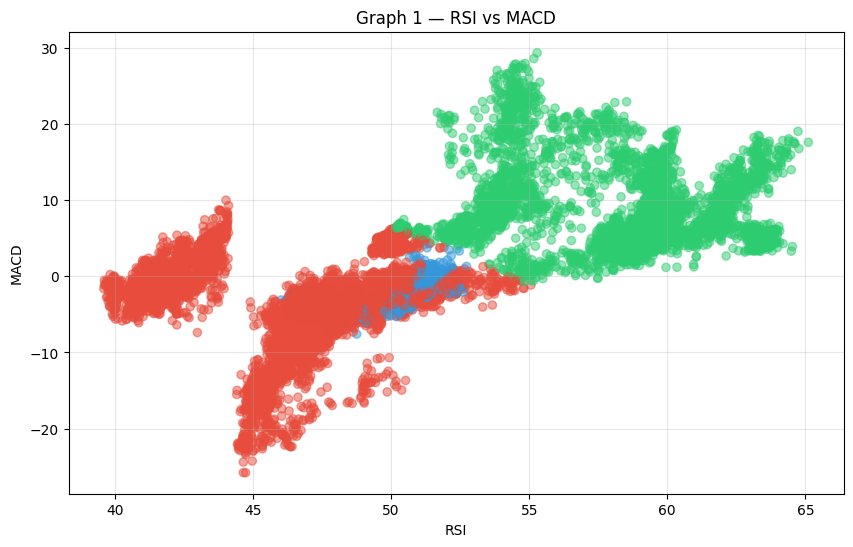

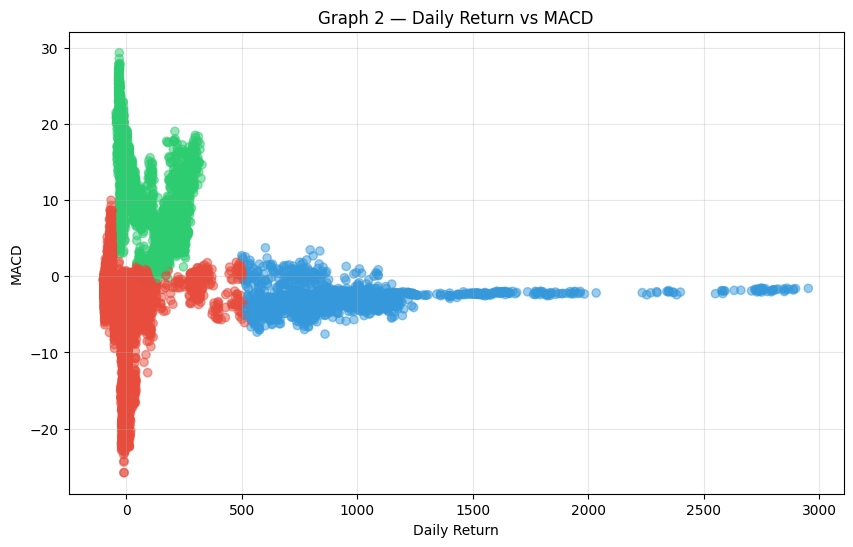

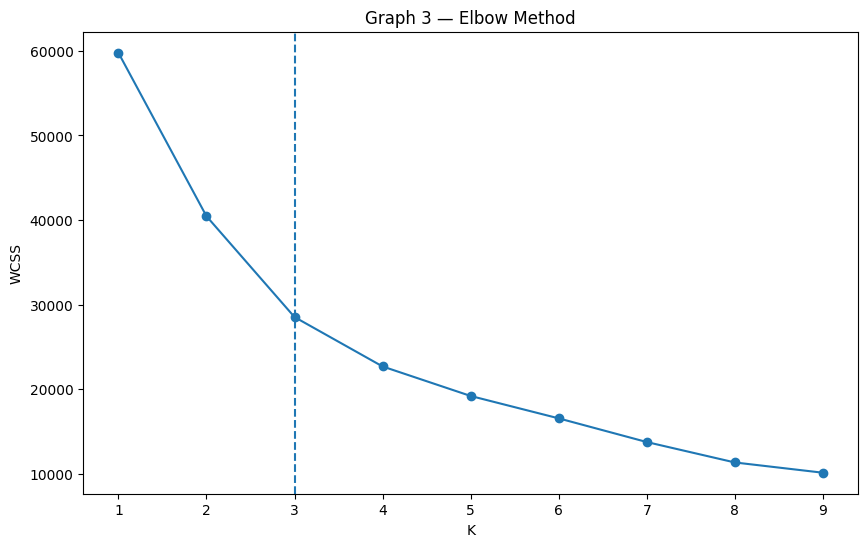

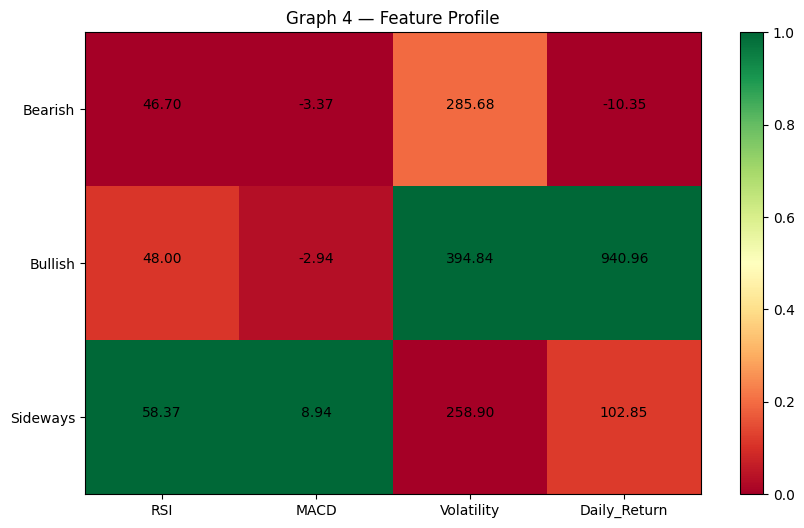

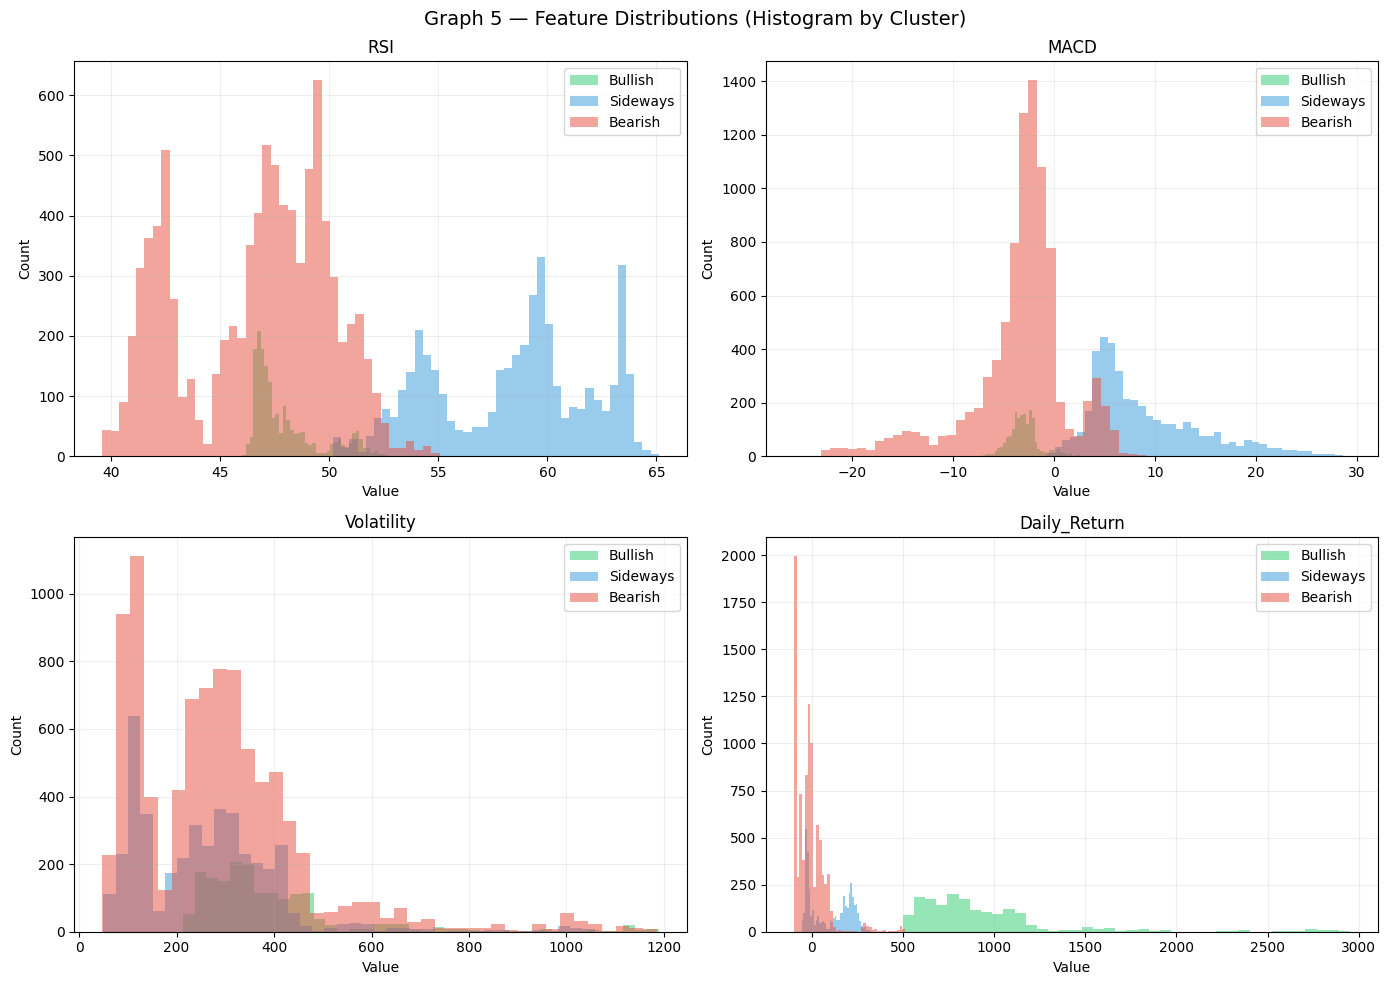

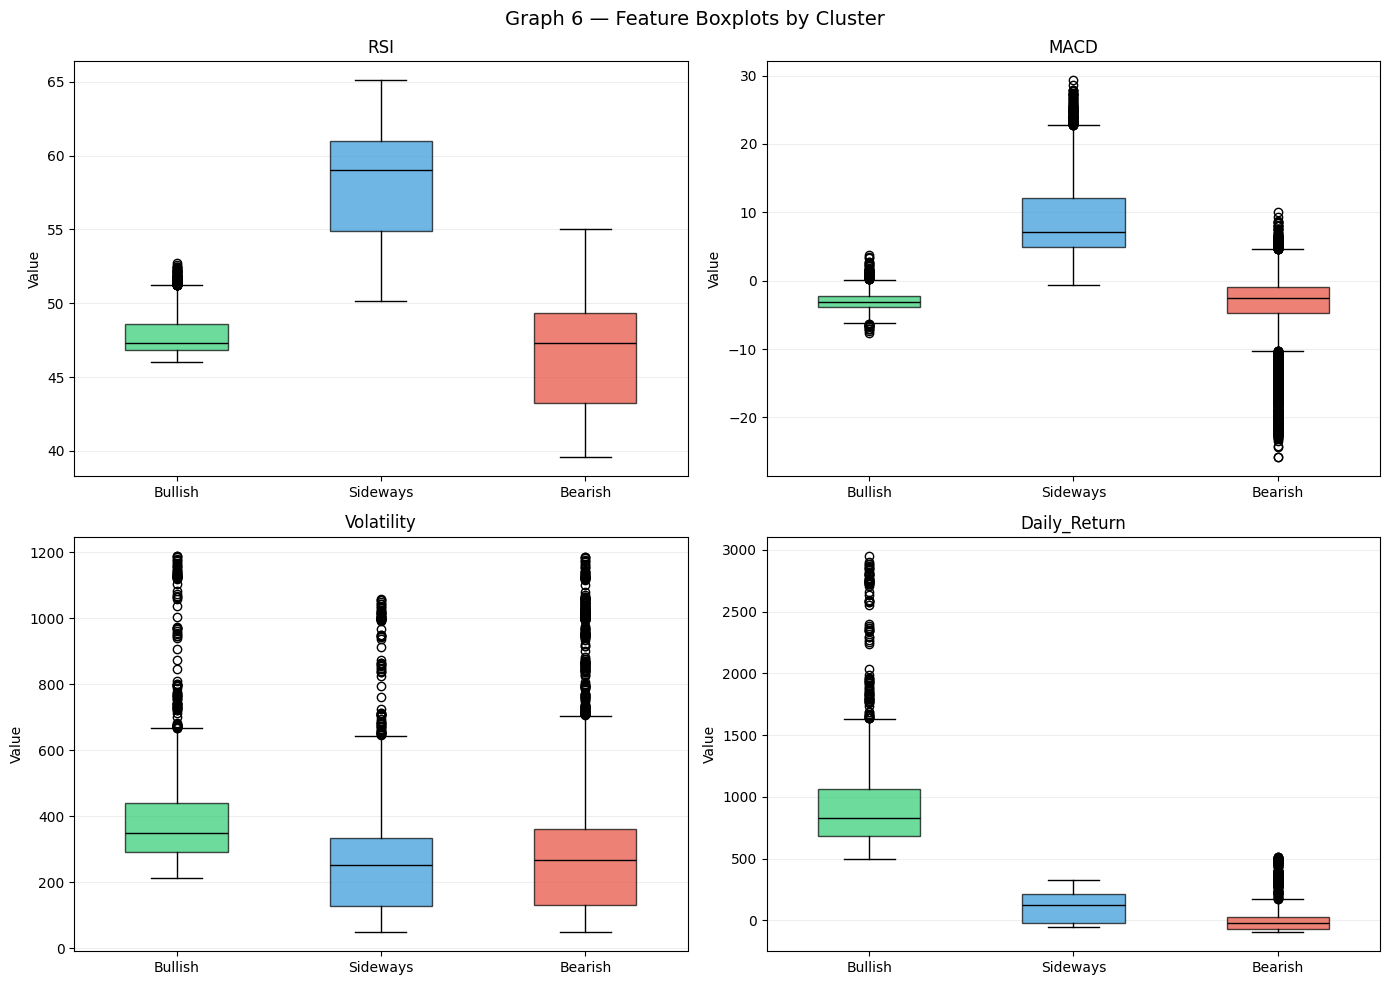

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import kagglehub
import os

# ─────────────────────────────────────────
# SETTINGS
# ─────────────────────────────────────────
BG = 'white'
TEXT = 'black'

palette = {0: '#2ecc71', 1: '#3498db', 2: '#e74c3c'}

# ─────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────
path = kagglehub.dataset_download("vishardmehta/faang-stock-market-data-with-technical-indicators")
print("Path to dataset files:", path)

# Find the CSV file inside the downloaded folder
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("CSV files found:", csv_files)

df = pd.read_csv(os.path.join(path, csv_files[0]))
df = df.select_dtypes(include=['float64', 'int64']).dropna()

df['Daily_Return'] = df['Close'].pct_change() * 100
df['Volatility'] = df['Daily_Return'].rolling(20).std()

delta = df['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

df['RSI'] = 100 - (100 / (1 + gain.ewm(span=14).mean() / loss.ewm(span=14).mean()))
df['MACD'] = df['Close'].ewm(span=12).mean() - df['Close'].ewm(span=26).mean()

df = df.dropna()

# ─────────────────────────────────────────
# CLUSTERING
# ─────────────────────────────────────────
features = ['RSI', 'MACD', 'Volatility', 'Daily_Return']
X = StandardScaler().fit_transform(df[features])

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Label mapping
cluster_means = df.groupby('Cluster')['Daily_Return'].mean().sort_values(ascending=False)

labels = {
    cluster_means.index[0]: 'Bullish',
    cluster_means.index[1]: 'Sideways',
    cluster_means.index[2]: 'Bearish'
}

df['Label'] = df['Cluster'].map(labels)
df['Color'] = df['Cluster'].map(palette)

# ─────────────────────────────────────────
# GRAPH 1 — RSI vs MACD
# ─────────────────────────────────────────
plt.figure(figsize=(10, 6), facecolor=BG)
plt.scatter(df['RSI'], df['MACD'], c=df['Color'], alpha=0.5)
plt.title("Graph 1 — RSI vs MACD", color=TEXT)
plt.xlabel("RSI", color=TEXT)
plt.ylabel("MACD", color=TEXT)
plt.grid(alpha=0.3)
plt.savefig("graph1.png", facecolor=BG)
plt.show()

# ─────────────────────────────────────────
# GRAPH 2 — Daily Return vs MACD
# ─────────────────────────────────────────
plt.figure(figsize=(10, 6), facecolor=BG)
plt.scatter(df['Daily_Return'], df['MACD'], c=df['Color'], alpha=0.5)
plt.title("Graph 2 — Daily Return vs MACD", color=TEXT)
plt.xlabel("Daily Return", color=TEXT)
plt.ylabel("MACD", color=TEXT)
plt.grid(alpha=0.3)
plt.savefig("graph2.png", facecolor=BG)
plt.show()

# ─────────────────────────────────────────
# GRAPH 3 — Elbow
# ─────────────────────────────────────────
wcss = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(10, 6), facecolor=BG)
plt.plot(range(1, 10), wcss, 'o-')
plt.axvline(3, linestyle='--')
plt.title("Graph 3 — Elbow Method", color=TEXT)
plt.xlabel("K", color=TEXT)
plt.ylabel("WCSS", color=TEXT)
plt.savefig("graph3.png", facecolor=BG)
plt.show()

# ─────────────────────────────────────────
# GRAPH 4 — HEATMAP
# ─────────────────────────────────────────
heat = df.groupby('Label')[features].mean()
norm = (heat - heat.min()) / (heat.max() - heat.min())

plt.figure(figsize=(10, 6), facecolor=BG)
plt.imshow(norm, cmap='RdYlGn')
plt.xticks(range(len(features)), features)
plt.yticks(range(len(heat.index)), heat.index)

for i in range(len(heat)):
    for j in range(len(features)):
        plt.text(j, i, f"{heat.values[i,j]:.2f}", ha='center')

plt.title("Graph 4 — Feature Profile", color=TEXT)
plt.colorbar()
plt.savefig("graph4.png", facecolor=BG)
plt.show()

# ─────────────────────────────────────────
# GRAPH 5 — HISTOGRAMS of Features
# ─────────────────────────────────────────
# Shows the distribution (spread and shape) of each feature.
# Each cluster is overlaid so you can see how Bullish/Sideways/Bearish differ.

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor=BG)
fig.suptitle("Graph 5 — Feature Distributions (Histogram by Cluster)", color=TEXT, fontsize=14)

label_color = {'Bullish': '#2ecc71', 'Sideways': '#3498db', 'Bearish': '#e74c3c'}

for ax, feat in zip(axes.flatten(), features):
    for lbl, color in label_color.items():
        subset = df[df['Label'] == lbl][feat]
        ax.hist(subset, bins=40, alpha=0.5, color=color, label=lbl, edgecolor='none')
    ax.set_title(feat, color=TEXT)
    ax.set_xlabel("Value", color=TEXT)
    ax.set_ylabel("Count", color=TEXT)
    ax.legend()
    ax.grid(alpha=0.2)
    ax.set_facecolor(BG)

plt.tight_layout()
plt.savefig("graph5_histograms.png", facecolor=BG)
plt.show()

# ─────────────────────────────────────────
# GRAPH 6 — BOXPLOTS of Features
# ─────────────────────────────────────────
# Shows median, spread, and outliers for each feature, grouped by cluster label.
# Great for spotting how much overlap there is between clusters.

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor=BG)
fig.suptitle("Graph 6 — Feature Boxplots by Cluster", color=TEXT, fontsize=14)

cluster_order = ['Bullish', 'Sideways', 'Bearish']
box_colors = [label_color[l] for l in cluster_order]

for ax, feat in zip(axes.flatten(), features):
    data_by_cluster = [df[df['Label'] == lbl][feat].dropna().values for lbl in cluster_order]

    bp = ax.boxplot(
        data_by_cluster,
        patch_artist=True,   # fills boxes with color
        notch=False,
        vert=True,
        widths=0.5
    )

    # Color each box
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Style whiskers and medians
    for element in ['whiskers', 'caps', 'medians', 'fliers']:
        for item in bp[element]:
            item.set_color(TEXT)

    ax.set_title(feat, color=TEXT)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(cluster_order, color=TEXT)
    ax.set_ylabel("Value", color=TEXT)
    ax.grid(axis='y', alpha=0.2)
    ax.set_facecolor(BG)

plt.tight_layout()
plt.savefig("graph6_boxplots.png", facecolor=BG)
plt.show()